# Notebook 2 — YOLO Model Training (YOLOv10 / YOLOv12 / YOLOv26)
## KIIT-MiTA: High-Resolution Drone Imagery for Military Object Detection

**CSE 445 — Computer Vision**

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

| Property | Value |
|---|---|
| **Dataset** | KIIT-MiTA (Military Target Detection), re-split output from Notebook 1 |
| **Source** | https://data.mendeley.com/datasets/drjmrf5kk5/1 |
| **Models trained here** | YOLOv10-s, YOLOv12-s, YOLOv26-s |
| **Hardware** | Kaggle T4 x1 (single GPU, `device=0`) |

This notebook covers **Task 4.5** for the three YOLO variants. 

---
## 1. Environment Setup
Install `ultralytics` (covers YOLOv10, YOLOv12, YOLOv26 through a single unified API) and locate the `data.yaml` produced by Notebook 1.

In [1]:
# install ultralytics (covers yolov10, yolov12, yolo26 through one API)
!pip install -q ultralytics

import os, json, time, pathlib, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from ultralytics import YOLO

print("ultralytics installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics installed.


In [2]:
# ==================== CONFIG CELL ====================
# All paths and shared settings live here. Do not hardcode dataset folder names.

import pathlib

def discover_data_yaml(search_base="/kaggle/input"):
    """Find the data.yaml produced by Notebook 1, wherever the resplit dataset was mounted."""
    search = pathlib.Path(search_base)
    if not search.exists():
        search = pathlib.Path(".")
    candidates = list(search.rglob("data.yaml"))
    if not candidates:
        raise FileNotFoundError(
            f"Could not find data.yaml under {search_base}. "
            "Make sure the Notebook 1 resplit dataset is added as an input."
        )
    return candidates[0]

DATA_YAML_ORIGINAL = discover_data_yaml()

with open(DATA_YAML_ORIGINAL) as f:
    _data_cfg = yaml.safe_load(f)

CLASS_NAMES = _data_cfg["names"]
NUM_CLASSES = _data_cfg["nc"]

_resplit_root = DATA_YAML_ORIGINAL.parent
_train_dir = _resplit_root / "train" / "images"
_val_dir = _resplit_root / "val" / "images"
_test_dir = _resplit_root / "test" / "images"

for _split_name, _split_dir in [("train", _train_dir), ("val", _val_dir), ("test", _test_dir)]:
    if not _split_dir.exists():
        raise FileNotFoundError(
            f"Expected {_split_name} images at {_split_dir} but it does not exist. "
            "Check that the Notebook 1 resplit dataset was added as an input correctly."
        )

DATA_YAML = pathlib.Path("/kaggle/working/data.yaml")
_fixed_cfg = {
    "train": str(_train_dir.resolve()),
    "val": str(_val_dir.resolve()),
    "test": str(_test_dir.resolve()),
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES,
}
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(_fixed_cfg, f, default_flow_style=False, sort_keys=False)

print(f"original data.yaml : {DATA_YAML_ORIGINAL}  (paths inside are stale, not used directly)")
print(f"corrected data.yaml : {DATA_YAML}")
print(f"  train : {_train_dir}")
print(f"  val   : {_val_dir}")
print(f"  test  : {_test_dir}")

IMG_SIZE = 640
DEVICE = 0               
SEED = 42
RUNS_ROOT = pathlib.Path("/kaggle/working/runs")
CHECKPOINT_DIR = pathlib.Path("/kaggle/working/checkpoints")
RESULTS_JSON = pathlib.Path("/kaggle/working/model_results.json")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_BASE = {
    "epochs": 100,
    "imgsz": IMG_SIZE,
    "batch": 32,
    "device": DEVICE,
    "optimizer": "AdamW",                     
    "lr0": 0.001,
    "weight_decay": 0.0005,                     
    "seed": SEED,
    "cls": 0.5,                             
    "patience": 20,          
    "cos_lr": True,
    "degrees": 15.0,           
    "flipud": 0.1,     
}

print(f"classes ({NUM_CLASSES})     : {CLASS_NAMES}")
print(f"image size          : {IMG_SIZE}")
print(f"device               : {DEVICE}")
print(f"checkpoint dir       : {CHECKPOINT_DIR}")
print(f"results log          : {RESULTS_JSON}")
print(f"\nCONFIG_BASE (shared by all three YOLO models):")
for k, v in CONFIG_BASE.items():
    print(f"  {k:12s}: {v}")


original data.yaml : /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/data.yaml  (paths inside are stale, not used directly)
corrected data.yaml : /kaggle/working/data.yaml
  train : /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/train/images
  val   : /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/val/images
  test  : /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/test/images
classes (7)     : ['Artilary', 'Missile', 'Radar', 'M. Rocket Launcher', 'Soldier', 'Tank', 'Vehicle']
image size          : 640
device               : 0
checkpoint dir       : /kaggle/working/checkpoints
results log          : /kaggle/working/model_results.json

CONFIG_BASE (shared by all three YOLO models):
  epochs      : 100
  imgsz       : 640
  batch       : 32
  device      : 0
  optimizer   : AdamW
  lr0         : 0.001
  weight_decay: 0.0005
  seed        : 42
  cls         : 0.5
  pa

---
### Runtime sanity check
Train split grew to 2,377 images after Notebook 1's copy-paste oversampling (was 1,339). Before committing all three models to a full 100-epoch run, time a couple of epochs on one model to estimate total runtime against the Kaggle session time budget.

In [3]:
# quick sanity check: time a handful of epochs on the largest model before
# committing to a full 100-epoch x 3-model run on the bigger train set
_probe = YOLO("yolov10s.pt")
_t0 = time.time()
_probe.train(data=str(DATA_YAML), epochs=2, imgsz=CONFIG_BASE["imgsz"],
             batch=CONFIG_BASE["batch"], device=CONFIG_BASE["device"],
             project=str(RUNS_ROOT), name="_time_probe", exist_ok=True, verbose=False)
_per_epoch_min = (time.time() - _t0) / 60 / 2
print(f"~{_per_epoch_min:.2f} min/epoch -> ~{_per_epoch_min*100:.0f} min for a full 100-epoch run, per model")
print(f"~{_per_epoch_min*100*3:.0f} min total for all three models back-to-back")

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=_time_probe, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [4]:
# DIAGNOSTIC — verify the Notebook 1 input attached to this notebook is
# complete and correct before training. Safe to delete after checking.

import pathlib

print("=" * 60)
print("NOTEBOOK 1 INPUT DIAGNOSTIC")
print("=" * 60)

# locate data.yaml the same way the real CONFIG cell does
_search = pathlib.Path("/kaggle/input")
_candidates = list(_search.rglob("data.yaml"))
print(f"data.yaml candidates found: {len(_candidates)}")
for c in _candidates:
    print(f"  {c}")

if not _candidates:
    raise FileNotFoundError("No data.yaml found under /kaggle/input. Check that Notebook 1 is attached as an input.")

_yaml_path = _candidates[0]
_resplit_root = _yaml_path.parent

print(f"\nUsing: {_yaml_path}")
print(f"Resplit root: {_resplit_root}")
print()

expected_counts = {"train": 2377, "val": 164, "test": 178}  # train count post copy-paste oversampling
all_ok = True

for split, expected in expected_counts.items():
    img_dir = _resplit_root / split / "images"
    lbl_dir = _resplit_root / split / "labels"

    print(f"--- {split} ---")
    print(f"  images dir exists  : {img_dir.exists()}")
    print(f"  labels dir exists  : {lbl_dir.exists()}")

    if not (img_dir.exists() and lbl_dir.exists()):
        print(f"  MISSING FOLDER for {split}")
        all_ok = False
        print()
        continue

    img_files = sorted(img_dir.glob("*"))
    lbl_files = sorted(lbl_dir.glob("*"))
    img_stems = {p.stem for p in img_files}
    lbl_stems = {p.stem for p in lbl_files}

    n_img = len(img_files)
    n_lbl = len(lbl_files)
    missing_labels = img_stems - lbl_stems
    orphan_labels = lbl_stems - img_stems

    print(f"  image count        : {n_img}  (expected {expected})")
    print(f"  label count        : {n_lbl}  (expected {expected})")
    print(f"  images w/o labels  : {len(missing_labels)}")
    print(f"  labels w/o images  : {len(orphan_labels)}")

    if n_img != expected or n_lbl != expected:
        print(f"  COUNT MISMATCH for {split}")
        all_ok = False
    if missing_labels or orphan_labels:
        print(f"  PAIRING MISMATCH for {split}")
        all_ok = False

    print()

print("--- cross-split overlap check ---")
stem_sets = {}
for split in expected_counts:
    img_dir = _resplit_root / split / "images"
    if img_dir.exists():
        stem_sets[split] = {p.stem for p in img_dir.glob("*")}

splits = list(stem_sets.keys())
for i in range(len(splits)):
    for j in range(i + 1, len(splits)):
        overlap = stem_sets[splits[i]] & stem_sets[splits[j]]
        print(f"  {splits[i]} vs {splits[j]}: {len(overlap)} overlapping stems")
        if overlap:
            all_ok = False

print()
print(f"data.yaml contents:")
with open(_yaml_path) as f:
    print(f.read())

print("=" * 60)
if all_ok:
    print("ALL CHECKS PASSED — safe to proceed with training.")
else:
    print("ISSUES FOUND — do not start training until resolved.")
print("=" * 60)

NOTEBOOK 1 INPUT DIAGNOSTIC
data.yaml candidates found: 1
  /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/data.yaml

Using: /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/data.yaml
Resplit root: /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit

--- train ---
  images dir exists  : True
  labels dir exists  : True
  image count        : 2377  (expected 2377)
  label count        : 2377  (expected 2377)
  images w/o labels  : 0
  labels w/o images  : 0

--- val ---
  images dir exists  : True
  labels dir exists  : True
  image count        : 164  (expected 164)
  label count        : 164  (expected 164)
  images w/o labels  : 0
  labels w/o images  : 0

--- test ---
  images dir exists  : True
  labels dir exists  : True
  image count        : 178  (expected 178)
  label count        : 178  (expected 178)
  images w/o labels  : 0
  labels w/o images  : 0

--- cross-split overlap check ---
  train

In [5]:
# ==================== SHARED TRAINING / LOGGING HELPERS ====================
import torch

def load_results_store(path):
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return {}

def save_results_store(store, path):
    with open(path, "w") as f:
        json.dump(store, f, indent=2)

def plot_training_curves(csv_path, model_name):
    """Plot loss and mAP curves from the Ultralytics results.csv of a run."""
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    loss_cols = [c for c in df.columns if "loss" in c]
    for c in loss_cols:
        axes[0].plot(df["epoch"], df[c], label=c)
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend(fontsize=7)

    map_cols = [c for c in df.columns if "mAP50" in c]
    for c in map_cols:
        axes[1].plot(df["epoch"], df[c], label=c)
    axes[1].set_title(f"{model_name} — mAP")
    axes[1].set_xlabel("epoch")
    axes[1].legend(fontsize=7)

    pr_cols = [c for c in df.columns if "precision" in c or "recall" in c]
    for c in pr_cols:
        axes[2].plot(df["epoch"], df[c], label=c)
    axes[2].set_title(f"{model_name} — Precision / Recall")
    axes[2].set_xlabel("epoch")
    axes[2].legend(fontsize=7)

    plt.tight_layout()
    plt.show()
    return df

def compute_mcc_from_confusion_matrix(cm):
    """
    Multiclass MCC (Gorodkin's generalisation) computed directly from an
    Ultralytics confusion matrix so we do not need to re-run inference in
    Notebook 4 just to get this number.
    """
    cm = np.array(cm, dtype=np.float64)
    t_k = cm.sum(axis=1)   # true count per class (rows)
    p_k = cm.sum(axis=0)   # predicted count per class (cols)
    c = np.trace(cm)
    s = cm.sum()

    numerator = c * s - np.dot(t_k, p_k)
    denom_1 = s ** 2 - np.dot(p_k, p_k)
    denom_2 = s ** 2 - np.dot(t_k, t_k)
    denominator = np.sqrt(denom_1 * denom_2)

    if denominator == 0:
        return 0.0
    return float(numerator / denominator)

def measure_inference_speed(model, data_yaml, imgsz, device, n_warmup=5, n_runs=50):
    """
    Single-image inference speed on the test split, one GPU, for a fair,
    comparable FPS number across all four models in Notebook 4.
    torch.cuda.synchronize() is called around each timed call so the CPU
    clock does not stop before the GPU has actually finished the forward
    pass (CUDA calls are asynchronous by default).
    """
    with open(data_yaml) as f:
        cfg = yaml.safe_load(f)
    test_dir = pathlib.Path(cfg["test"])
    test_images = sorted(test_dir.glob("*"))[:n_runs + n_warmup]

    for img_path in test_images[:n_warmup]:
        model.predict(str(img_path), imgsz=imgsz, device=device, verbose=False)

    times = []
    for img_path in test_images[n_warmup:]:
        torch.cuda.synchronize()
        t0 = time.time()
        model.predict(str(img_path), imgsz=imgsz, device=device, verbose=False)
        torch.cuda.synchronize()
        times.append(time.time() - t0)

    mean_time = float(np.mean(times)) if times else float("nan")
    fps = 1.0 / mean_time if mean_time > 0 else float("nan")
    return {"ms_per_image": mean_time * 1000, "fps": fps, "n_images_timed": len(times)}

def copy_checkpoints_flat(model_key, best_pt, last_pt, checkpoint_dir):
    """
    Copy best.pt / last.pt into a single flat folder with model-name-prefixed
    filenames, so Notebook 4 can load all four checkpoints from one directory
    instead of digging through nested run folders.
    """
    import shutil
    flat_best = checkpoint_dir / f"{model_key}_best.pt"
    flat_last = checkpoint_dir / f"{model_key}_last.pt"
    shutil.copy2(str(best_pt), str(flat_best))
    shutil.copy2(str(last_pt), str(flat_last))
    return str(flat_best), str(flat_last)

def train_and_log(model_key, weights_name, config, data_yaml, class_names, results_store):
    """
    Train one YOLO variant, validate it, collect everything Notebook 4 needs,
    and write it into the shared results_store dict (also saved to disk).
    """
    print("=" * 60)
    print(f"TRAINING: {model_key}")
    print("=" * 60)

    model = YOLO(weights_name)
    t_start = time.time()

    train_results = model.train(
        data=str(data_yaml),
        epochs=config["epochs"],
        imgsz=config["imgsz"],
        batch=config["batch"],
        device=config["device"],
        optimizer=config["optimizer"],
        lr0=config["lr0"],
        weight_decay=config.get("weight_decay", 0.0005),
        seed=config["seed"],
        cls=config.get("cls", 0.5),         # classification loss gain (imbalance handling)
        patience=config.get("patience", 100),  # early stopping
        cos_lr=config.get("cos_lr", False),  # cosine LR decay vs Ultralytics' default linear decay
        degrees=config.get("degrees", 0.0),  # rotation range -- aerial imagery has no canonical "up"
        flipud=config.get("flipud", 0.0),    # vertical flip prob -- same reasoning as degrees
        project=str(RUNS_ROOT),
        name=model_key,
        exist_ok=True,
    )
    training_minutes = (time.time() - t_start) / 60

    run_dir = pathlib.Path(train_results.save_dir)
    best_pt = run_dir / "weights" / "best.pt"
    last_pt = run_dir / "weights" / "last.pt"
    flat_best, flat_last = copy_checkpoints_flat(model_key, best_pt, last_pt, CHECKPOINT_DIR)

    curves_df = plot_training_curves(run_dir / "results.csv", model_key)

    best_model = YOLO(str(best_pt))
    val_results = best_model.val(data=str(data_yaml), imgsz=config["imgsz"], split="test")

    cm = val_results.confusion_matrix.matrix.tolist()
    mcc = compute_mcc_from_confusion_matrix(cm)

    per_class = {}
    for i, name in enumerate(class_names):
        per_class[name] = {
            "precision": float(val_results.box.p[i]) if i < len(val_results.box.p) else None,
            "recall": float(val_results.box.r[i]) if i < len(val_results.box.r) else None,
            "mAP50": float(val_results.box.ap50[i]) if i < len(val_results.box.ap50) else None,
            "mAP50_95": float(val_results.box.ap[i]) if i < len(val_results.box.ap) else None,
            "f1": float(val_results.box.f1[i]) if i < len(val_results.box.f1) else None,
        }

    speed_info = measure_inference_speed(best_model, data_yaml, config["imgsz"], config["device"])

    n_params = sum(p.numel() for p in best_model.model.parameters())
    model_size_mb = best_pt.stat().st_size / (1024 * 1024)

    results_store[model_key] = {
        "config": config,
        "checkpoints": {
            "best_pt": str(best_pt), "last_pt": str(last_pt),
            "best_pt_flat": flat_best, "last_pt_flat": flat_last,
        },
        "training_history": curves_df.to_dict(orient="list"),
        "final_metrics": {
            "mAP50": float(val_results.box.map50),
            "mAP50_95": float(val_results.box.map),
            "precision": float(val_results.box.mp),
            "recall": float(val_results.box.mr),
            "f1": float(np.mean(val_results.box.f1)) if len(val_results.box.f1) else None,
            "mcc": mcc,
            "per_class": per_class,
            "confusion_matrix": {"labels": list(class_names) + ["background"], "matrix": cm},
        },
        "inference": {
            **speed_info,
            "params_millions": n_params / 1e6,
            "model_size_mb": model_size_mb,
            "device_used": f"GPU {config['device']}",
        },
        "training_time_minutes": training_minutes,
    }

    save_results_store(results_store, RESULTS_JSON)

    print(f"\n{model_key} done in {training_minutes:.1f} min")
    print(f"mAP50={val_results.box.map50:.4f}  mAP50-95={val_results.box.map:.4f}  MCC={mcc:.4f}")
    print(f"checkpoints copied to: {flat_best}, {flat_last}")

    return results_store

results_store = load_results_store(RESULTS_JSON)
print("Helpers ready. Existing logged models:", list(results_store.keys()))


Helpers ready. Existing logged models: []


---
## 2. YOLOv10-s

Uses `CONFIG_BASE` from the global CONFIG cell — same hyperparameters as YOLOv12-s and YOLOv26-s so any performance difference in Notebook 4 reflects architecture, not tuning.

**Justification (applies to all three models, since the config is shared):**
- `epochs=100` — assignment minimum was 50;
- `imgsz=640` — matches the resolution used in Notebook 1 EDA and augmentation pipeline.
- `batch=32` — fits comfortably in a single T4's 16GB VRAM for the `s` scale at this resolution.
- `optimizer='AdamW'` — set explicitly rather than left on `'auto'`. Our earlier `'auto'` run resolved to AdamW anyway (Ultralytics' own heuristic picked `AdamW(lr=0.000909)` for this dataset size), so this states the same choice directly instead of relying on an implicit heuristic decision.
- `lr0=0.001` — a standard AdamW starting learning rate for fine-tuning pretrained weights on a small dataset; higher SGD-style rates (e.g. 0.01) are not appropriate for AdamW.
- `weight_decay=0.0005` — Ultralytics' own default value, stated explicitly for the same reason as the optimizer choice.
- `cls=0.5` — kept at the Ultralytics default rather than raised. Notebook 1's copy-paste oversampling (Section 4.1) already reduced train-split instance imbalance from 4.10x to 1.69x (minority classes: Artilary, Radar, M. Rocket Launcher, Missile), so the imbalance is now handled primarily at the data level. An earlier run with `cls=0.7` on the *pre-oversampling* data raised recall on some classes but consistently lowered precision across all three models; stacking that same loss-level correction on top of the now-rebalanced data risks the same overcorrection without the earlier justification for it. Current Ultralytics no longer exposes `fl_gamma` as a `train()` argument (it was a YOLOv5-era hyperparameter); Focal Loss is still used internally with a fixed gamma, so `cls` gain remains the supported lever if this needs revisiting later.
- `device=0` — single GPU, kept explicit so the same device is used for training and for the inference-speed measurement, making FPS comparable across all four models in Notebook 4.
- `patience=20` — enables early stopping. Ultralytics' own default is `patience=100`, which cannot trigger inside a 50-epoch run at all; raised from an earlier `patience=15` because the 164-image val split produces a noisier epoch-to-epoch mAP signal than a larger set would, so a slightly longer window avoids stopping on a temporary dip rather than genuine convergence.
- `cos_lr=True` — cosine LR decay, set explicitly instead of relying on Ultralytics' default linear decay, so the learning-rate schedule is documented rather than implicit.
- `degrees=15.0`, `flipud=0.1` — **augmentation-wiring note:** Notebook 1 Section 4 designed and verified a standalone Albumentations pipeline (`VerticalFlip p=0.1`, `ShiftScaleRotate ±15°`, among others), justified specifically because this is aerial drone imagery with no canonical "up." That `Compose` object cannot be passed into Ultralytics' `train()` — the trainer owns its own dataloader and augmentation pipeline, so an external Albumentations object has no wiring path into it regardless of how it's called. Left unconfigured, Ultralytics' defaults are `degrees=0.0, flipud=0.0` — silently dropping the one augmentation choice NB1 justified as dataset-critical. `degrees` and `flipud` are set here as native `train()` arguments to restore that same design intent through the mechanism that actually affects training. The remaining NB1 transforms (`Blur/GaussNoise/CLAHE`) are not reproduced here: Ultralytics' own internal Albumentations wrapper already applies `Blur/MedianBlur/ToGray/CLAHE` at a conservative `p=0.01`, which is consistent with — not a violation of — NB1's own earlier decision to remove aggressive blur/noise because it degraded clarity on small targets (Radar, Artilary).

If a model ever needs a different value, only its `override` dict below changes — `CONFIG_BASE` itself stays untouched.

In [6]:
# no overrides needed for YOLOv10-s — uses CONFIG_BASE as-is
CONFIG_YOLOV10 = {**CONFIG_BASE}

print("YOLOv10-s config:")
for k, v in CONFIG_YOLOV10.items():
    print(f"  {k:12s}: {v}")


YOLOv10-s config:
  epochs      : 100
  imgsz       : 640
  batch       : 32
  device      : 0
  optimizer   : AdamW
  lr0         : 0.001
  weight_decay: 0.0005
  seed        : 42
  cls         : 0.5
  patience    : 20
  cos_lr      : True
  degrees     : 15.0
  flipud      : 0.1


TRAINING: yolov10s
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10s, nbs=64, nms=False, opset=None, optimize=False, optimizer=

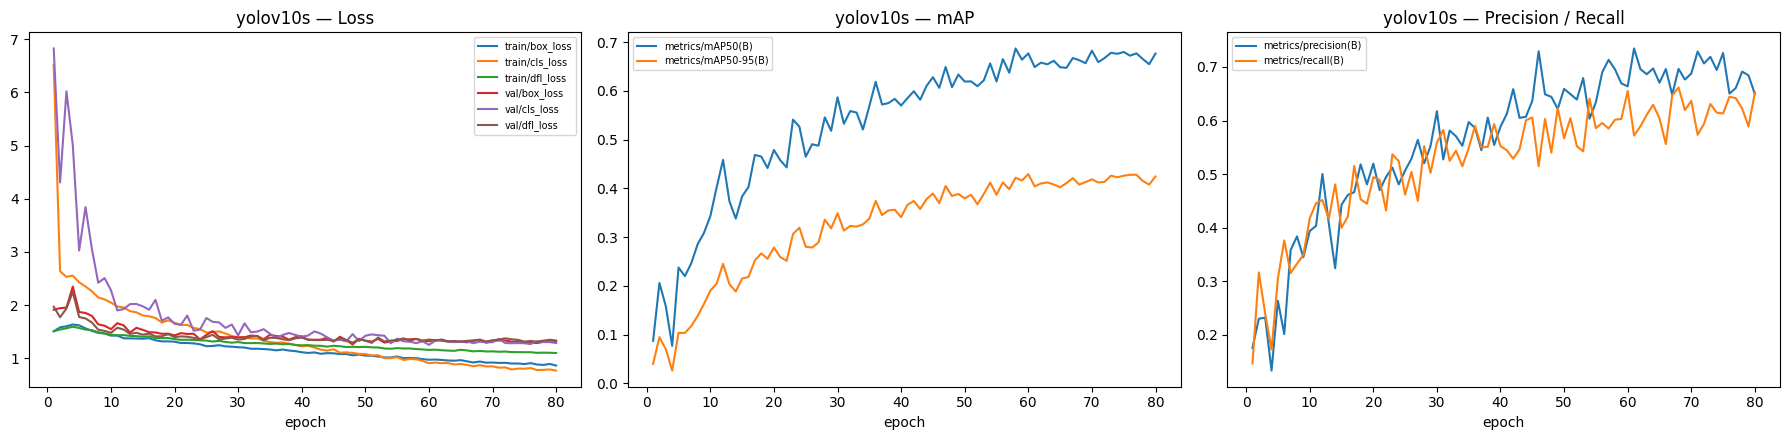

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv10s summary (fused): 106 layers, 7,220,709 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.9 ms, read: 10.9±5.6 MB/s, size: 56.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/test/labels... 178 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 178/178 221.7it/s 0.8s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 4.0it/s 3.0s
                   all        178        483       0.67      0.649      0.668      0.428
              Artilary         16         28 

In [7]:
results_store = train_and_log(
    model_key="yolov10s",
    weights_name="yolov10s.pt",
    config=CONFIG_YOLOV10,
    data_yaml=DATA_YAML,
    class_names=CLASS_NAMES,
    results_store=results_store,
)


---
## 3. YOLOv12-s

Same `CONFIG_BASE`, no overrides.

In [8]:
# no overrides needed for YOLOv12-s — uses CONFIG_BASE as-is
CONFIG_YOLOV12 = {**CONFIG_BASE}

print("YOLOv12-s config:")
for k, v in CONFIG_YOLOV12.items():
    print(f"  {k:12s}: {v}")


YOLOv12-s config:
  epochs      : 100
  imgsz       : 640
  batch       : 32
  device      : 0
  optimizer   : AdamW
  lr0         : 0.001
  weight_decay: 0.0005
  seed        : 42
  cls         : 0.5
  patience    : 20
  cos_lr      : True
  degrees     : 15.0
  flipud      : 0.1


TRAINING: yolov12s
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov12s, nbs=64, nms=False, opset=None, optimize=False, optimizer=A

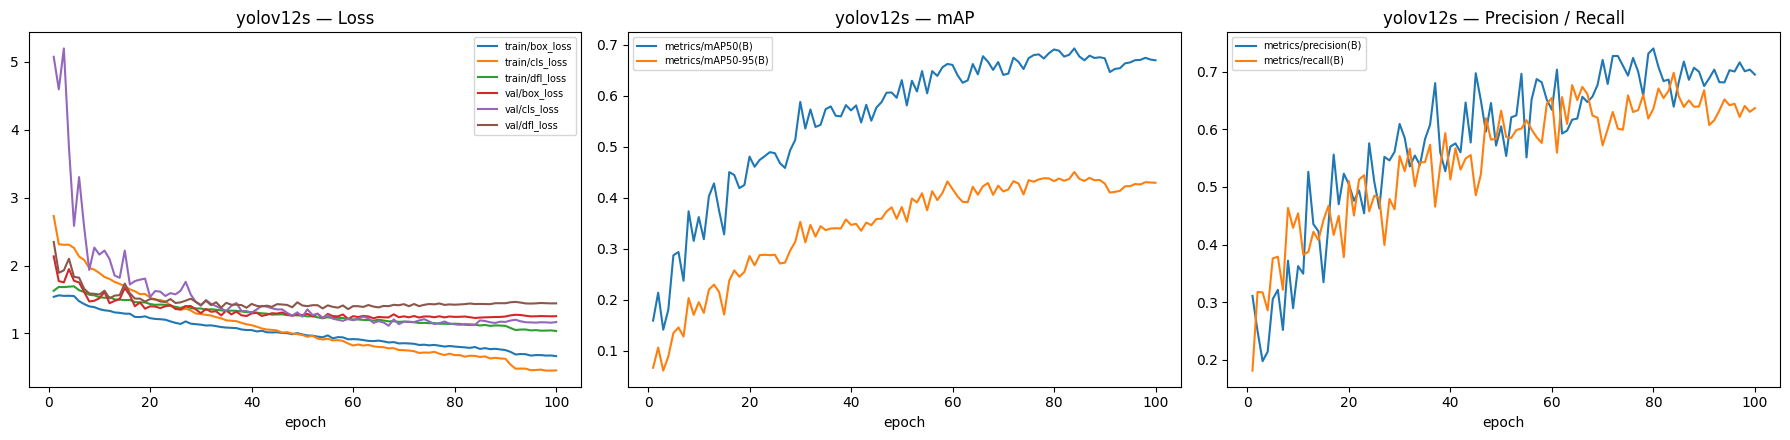

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv12s summary (fused): 159 layers, 9,233,589 parameters, 0 gradients, 21.2 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.4 ms, read: 97.2±61.0 MB/s, size: 56.7 KB)
val: Scanning /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/test/labels... 178 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 178/178 572.1it/s 0.3s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.2it/s 3.7s
                   all        178        483      0.746      0.531      0.642      0.427
              Artilary         16         28      0.827      0.536      0.659      0.334
               Missile         30         45      0.661      0.477       0.55      0.406
                 Radar

In [9]:
results_store = train_and_log(
    model_key="yolov12s",
    weights_name="yolo12s.pt",
    config=CONFIG_YOLOV12,
    data_yaml=DATA_YAML,
    class_names=CLASS_NAMES,
    results_store=results_store,
)


---
## 4. YOLOv26-s

Same `CONFIG_BASE`, no overrides. One architectural note: YOLOv26 removes Distribution Focal Loss (DFL) and is natively NMS-free with a one-to-one detection head, so its internal loss composition differs from YOLOv10/v12 even though the training-call arguments here are identical.

In [10]:
# no overrides needed for YOLOv26-s — uses CONFIG_BASE as-is
CONFIG_YOLOV26 = {**CONFIG_BASE}

print("YOLOv26-s config:")
for k, v in CONFIG_YOLOV26.items():
    print(f"  {k:12s}: {v}")


YOLOv26-s config:
  epochs      : 100
  imgsz       : 640
  batch       : 32
  device      : 0
  optimizer   : AdamW
  lr0         : 0.001
  weight_decay: 0.0005
  seed        : 42
  cls         : 0.5
  patience    : 20
  cos_lr      : True
  degrees     : 15.0
  flipud      : 0.1


TRAINING: yolov26s
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov26s, nbs=64, nms=False, opset=None, optimize=False, optimizer=A

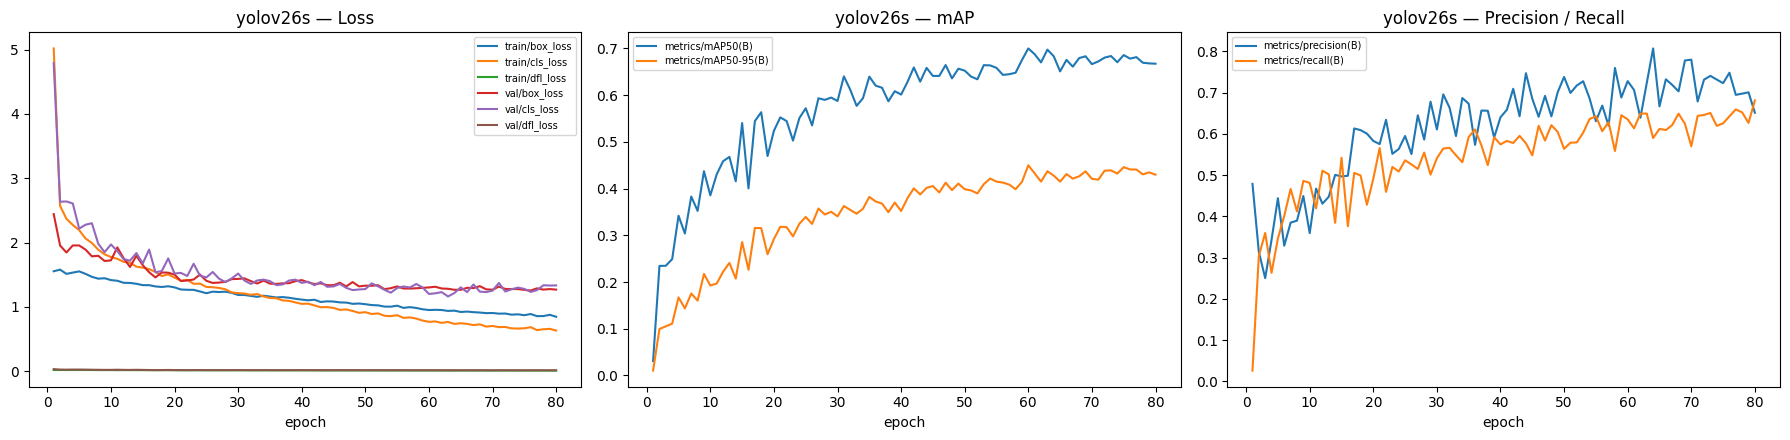

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26s summary (fused): 122 layers, 9,467,889 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.4 ms, read: 109.7±53.0 MB/s, size: 56.7 KB)
val: Scanning /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/test/labels... 178 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 178/178 667.9it/s 0.3s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.7it/s 3.2s
                   all        178        483      0.622      0.659      0.651      0.436
              Artilary         16         28      0.737      0.643      0.623      0.354
               Missile         30         45      0.452       0.44      0.486      0.342
                 Radar

In [11]:
results_store = train_and_log(
    model_key="yolov26s",
    weights_name="yolo26s.pt",
    config=CONFIG_YOLOV26,
    data_yaml=DATA_YAML,
    class_names=CLASS_NAMES,
    results_store=results_store,
)


---
## 5. Side-by-Side Training Curve Comparison

Loss, mAP@50, mAP@50-95, and precision/recall overlaid across all three models, so Task 4.5's training curves are compared directly rather than only through the final summary table.


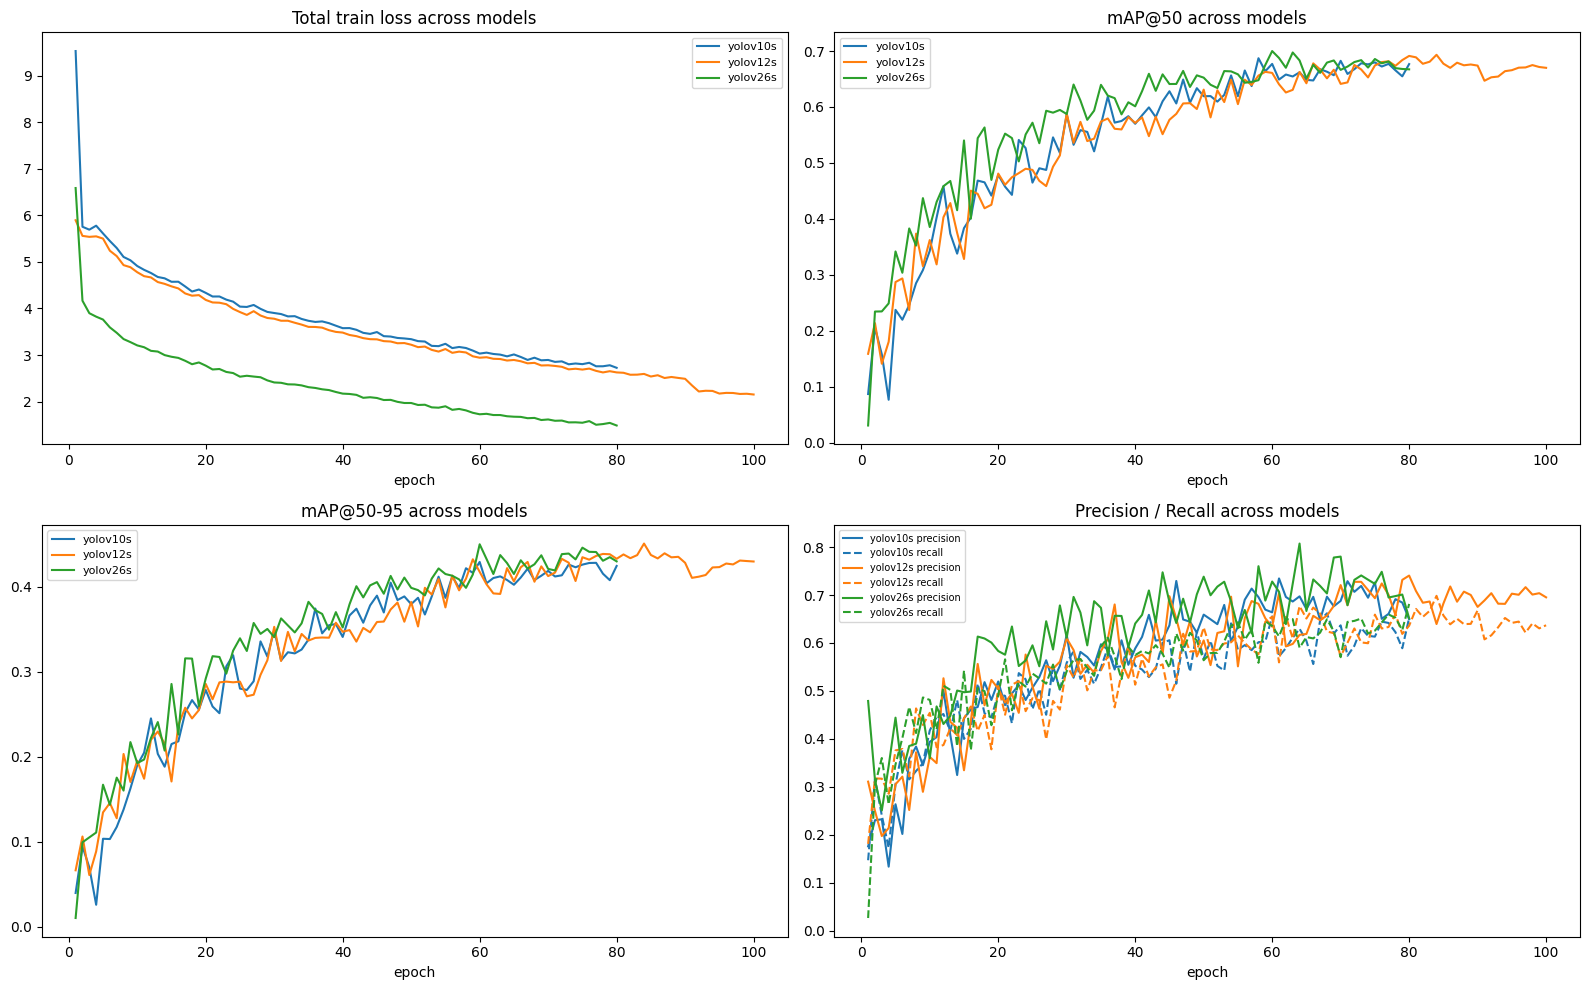

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

model_keys = ["yolov10s", "yolov12s", "yolov26s"]
colors = plt.cm.tab10.colors

for idx, model_key in enumerate(model_keys):
    if model_key not in results_store:
        continue
    hist = results_store[model_key]["training_history"]
    epochs = hist["epoch"]
    color = colors[idx]

    loss_cols = [c for c in hist if "loss" in c and "train" in c]
    if loss_cols:
        total_loss = [sum(hist[c][i] for c in loss_cols) for i in range(len(epochs))]
        axes[0, 0].plot(epochs, total_loss, label=model_key, color=color)

    map50_col = next((c for c in hist if "mAP50" in c and "95" not in c), None)
    if map50_col:
        axes[0, 1].plot(epochs, hist[map50_col], label=model_key, color=color)

    map5095_col = next((c for c in hist if "mAP50-95" in c or "mAP50_95" in c), None)
    if map5095_col:
        axes[1, 0].plot(epochs, hist[map5095_col], label=model_key, color=color)

    precision_col = next((c for c in hist if "precision" in c), None)
    recall_col = next((c for c in hist if "recall" in c), None)
    if precision_col:
        axes[1, 1].plot(epochs, hist[precision_col], label=f"{model_key} precision", color=color, linestyle="-")
    if recall_col:
        axes[1, 1].plot(epochs, hist[recall_col], label=f"{model_key} recall", color=color, linestyle="--")

axes[0, 0].set_title("Total train loss across models")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].legend(fontsize=8)

axes[0, 1].set_title("mAP@50 across models")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].legend(fontsize=8)

axes[1, 0].set_title("mAP@50-95 across models")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].legend(fontsize=8)

axes[1, 1].set_title("Precision / Recall across models")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].legend(fontsize=7)

plt.tight_layout()
plt.show()


---
## 6. Summary Table — Configuration and Final Metrics

In [13]:
summary_rows = []
for model_key, data in results_store.items():
    fm = data["final_metrics"]
    inf = data["inference"]
    summary_rows.append({
        "Model": model_key,
        "Epochs": data["config"]["epochs"],
        "Batch": data["config"]["batch"],
        "Optimizer": data["config"]["optimizer"],
        "LR0": data["config"]["lr0"],
        "weight_decay": data["config"].get("weight_decay"),
        "cls": data["config"].get("cls"),
        "patience": data["config"].get("patience"),
        "cos_lr": data["config"].get("cos_lr"),
        "degrees": data["config"].get("degrees"),
        "flipud": data["config"].get("flipud"),
        "mAP50": round(fm["mAP50"], 4),
        "mAP50-95": round(fm["mAP50_95"], 4),
        "Precision": round(fm["precision"], 4),
        "Recall": round(fm["recall"], 4),
        "F1": round(fm["f1"], 4) if fm["f1"] is not None else None,
        "MCC": round(fm["mcc"], 4),
        "FPS": round(inf["fps"], 2),
        "Params (M)": round(inf["params_millions"], 2),
        "Size (MB)": round(inf["model_size_mb"], 2),
        "Train time (min)": round(data["training_time_minutes"], 1),
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

print(f"\nAll results and checkpoint paths saved to: {RESULTS_JSON}")
print("This file is read directly in Notebook 4 for evaluation and error analysis.")


,Model,Epochs,Batch,Optimizer,LR0,weight_decay,cls,patience,cos_lr,degrees,...,mAP50,mAP50-95,Precision,Recall,F1,MCC,FPS,Params (M),Size (MB),Train time (min)
0,yolov10s,100,32,AdamW,0.001,0.0005,0.5,20,True,15.0,...,0.6678,0.4279,0.6696,0.6495,0.6575,0.4115,40.77,7.22,15.77,73.7
1,yolov12s,100,32,AdamW,0.001,0.0005,0.5,20,True,15.0,...,0.6424,0.4267,0.7463,0.5314,0.6150,0.3663,41.23,9.23,18.07,118.5
2,yolov26s,100,32,AdamW,0.001,0.0005,0.5,20,True,15.0,...,0.6509,0.4362,0.6221,0.6586,0.6359,0.4107,49.68,9.47,19.38,71.7



All results and checkpoint paths saved to: /kaggle/working/model_results.json
This file is read directly in Notebook 4 for evaluation and error analysis.


---
## 7. Output Verification for Notebook 4

Everything Notebook 4 needs lives under `/kaggle/working`:
- `checkpoints/` — flat folder with `best.pt` / `last.pt` for all three models
- `model_results.json` — metrics, confusion matrices, per-class scores, inference speed, checkpoint paths

In [14]:
# quick check that everything Notebook 4 needs is actually on disk before
# you publish this notebook's output as a Kaggle Dataset

print("Checkpoints in", CHECKPOINT_DIR, ":")
for p in sorted(CHECKPOINT_DIR.glob("*.pt")):
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"  {p.name}  ({size_mb:.1f} MB)")

print(f"\nresults json exists : {RESULTS_JSON.exists()}")
print(f"models logged        : {list(results_store.keys())}")

expected_models = {"yolov10s", "yolov12s", "yolov26s"}
missing = expected_models - set(results_store.keys())
if missing:
    print(f"\nWARNING — missing results for: {missing}")
else:
    print("\nAll three models logged. Ready to publish as a Kaggle Dataset output.")


Checkpoints in /kaggle/working/checkpoints :
  yolov10s_best.pt  (15.8 MB)
  yolov10s_last.pt  (15.8 MB)
  yolov12s_best.pt  (18.1 MB)
  yolov12s_last.pt  (18.1 MB)
  yolov26s_best.pt  (19.4 MB)
  yolov26s_last.pt  (19.4 MB)

results json exists : True
models logged        : ['yolov10s', 'yolov12s', 'yolov26s']

All three models logged. Ready to publish as a Kaggle Dataset output.
